In [1]:
#%%
import torch
import numpy as np
import pickle
import matplotlib.pyplot as plt


In [2]:
#change the working directory
import os
os.chdir('/home/shij0d/Documents/Dis_Spatial/')


[]


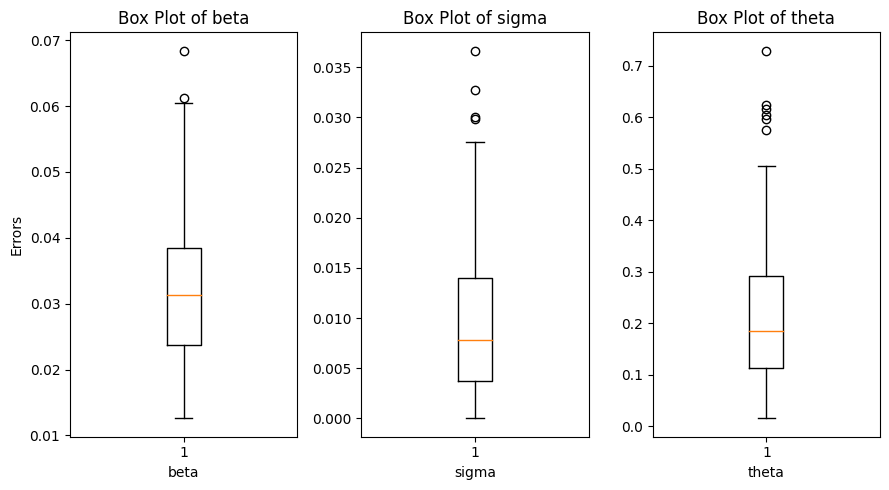

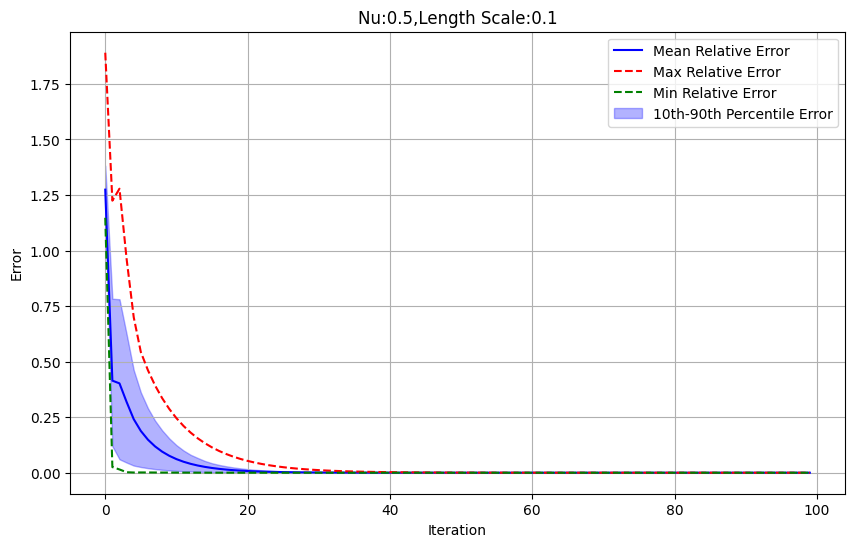

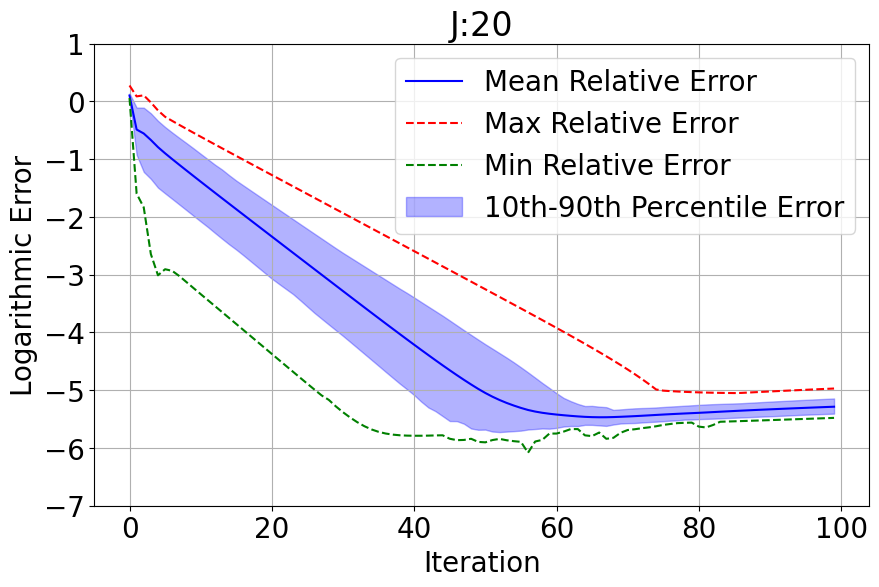

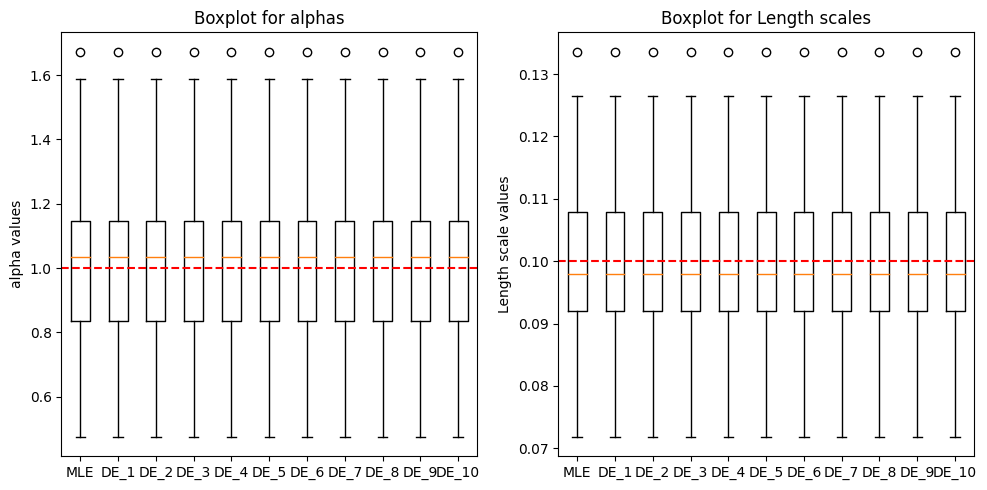

[]


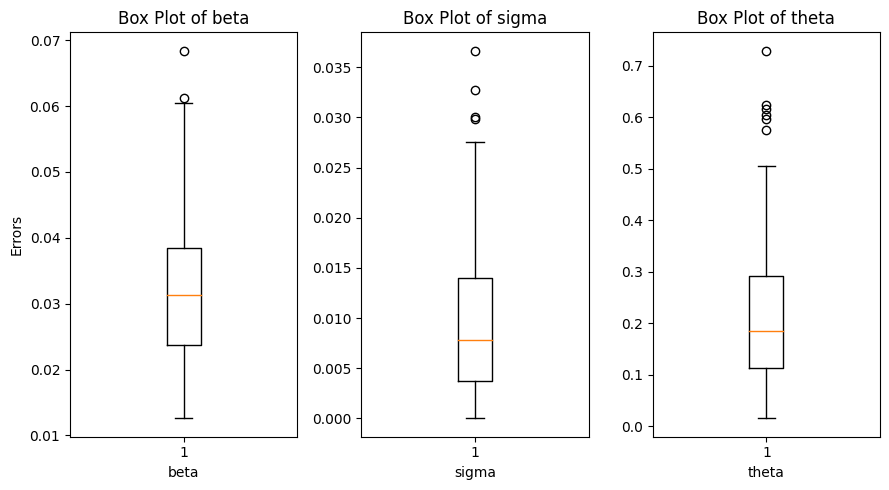

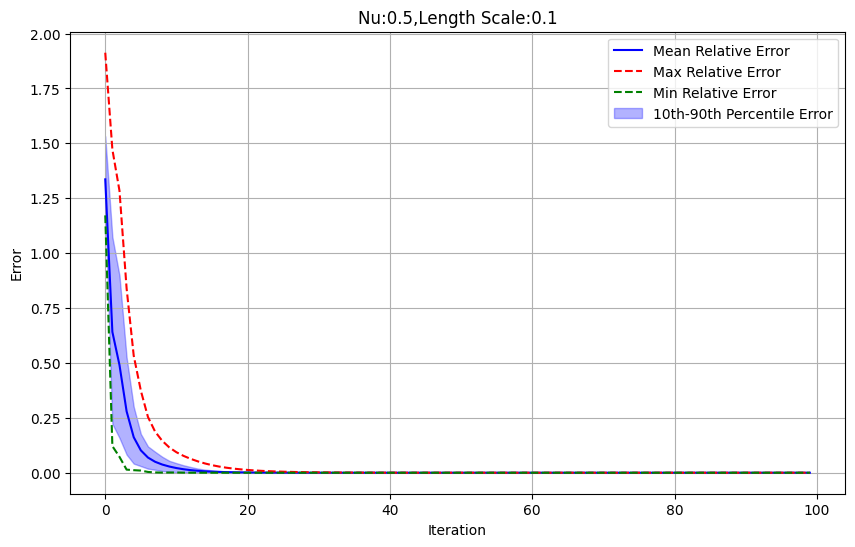

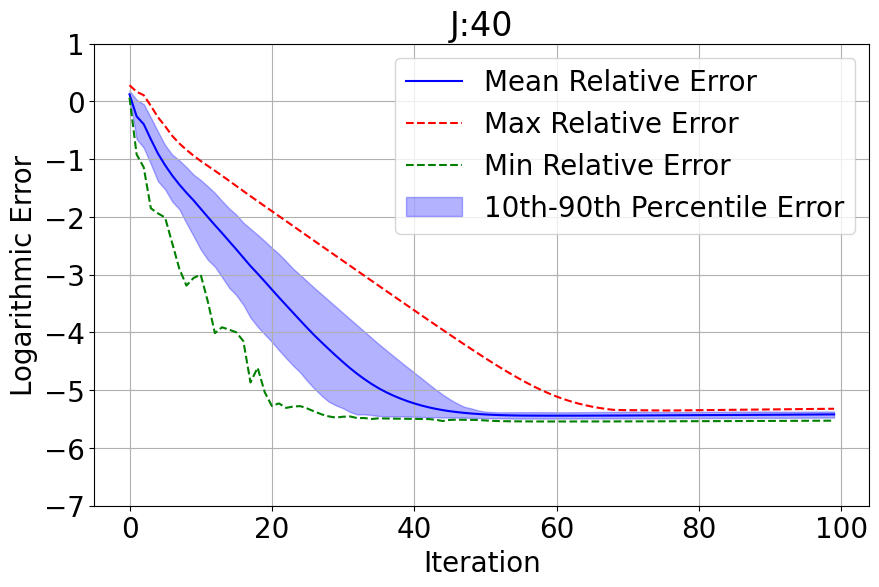

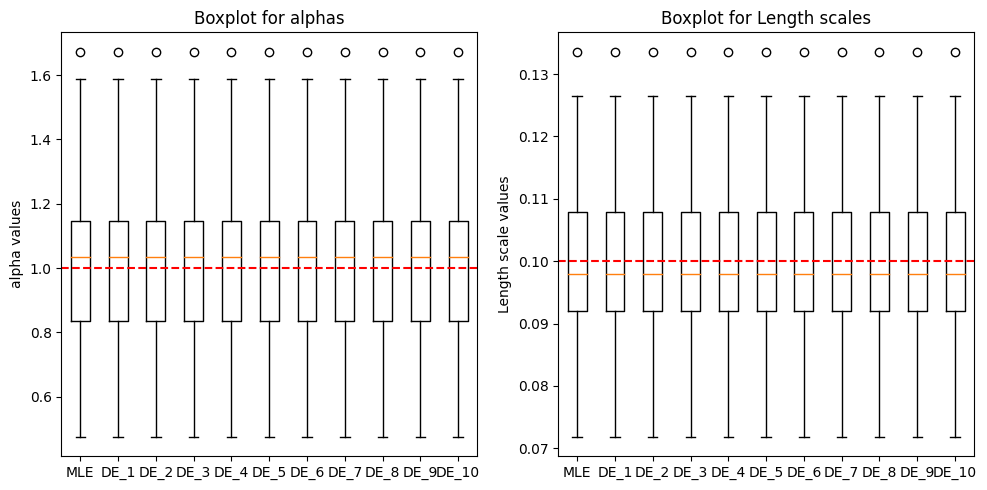

In [ ]:
theta=torch.tensor([1,0.1],dtype=torch.float64)
length_scale=0.1
nu=0.5
beta=torch.tensor([-1,2,3,-2,1],dtype=torch.float64)
delta=torch.tensor(0.25,dtype=torch.float64)
alpha=1
Js=[20,40]
for J in Js:
    with open(f'expriements/decentralized/varying_network/more_irregular/sparse/J_{J}_memeff.pkl', 'rb') as f:
        results=pickle.load(f)
    param_rel_error=np.zeros(shape=(100,100))
    sta_error_beta=np.zeros(shape=(100,))
    sta_error_delta=np.zeros(shape=(100,))
    sta_error_theta=np.zeros(shape=(100,))
    
    for r in range(100):

        sta_error_beta[r]=torch.norm((results[r][1][2].squeeze()-beta)/torch.abs(beta))
        sta_error_delta[r]=torch.norm((results[r][1][3].squeeze()-delta)/torch.abs(delta))
        sta_error_theta[r]=torch.norm((results[r][1][4].squeeze()-theta)/torch.abs(theta))
        for t in range(100):
            rel_error=torch.zeros((J,))
            for j in range(J):
                rel_dif_beta=torch.abs(results[r][0][2][t][j]-results[r][1][2]).squeeze()/torch.abs(beta)
                rel_dif_delta=torch.abs(results[r][0][3][t][j]-results[r][1][3]).squeeze()/torch.abs(delta)
                rel_dif_theta=torch.abs(results[r][0][4][t][j]-results[r][1][4]).squeeze()/torch.abs(theta)
                rel_error[j]=torch.sqrt(torch.square(torch.norm(rel_dif_beta))+torch.square(torch.norm(rel_dif_delta))+torch.square(torch.norm(rel_dif_theta)))
            param_rel_error[r,t]=rel_error.max().numpy()
    # Calculate the mean, standard deviation, max, and min across replications for each iteration
    
    mean_rel_error= np.mean(param_rel_error, axis=0)
    std_rel_error = np.std(param_rel_error, axis=0)
    percentile_10_error = np.percentile(param_rel_error, 10, axis=0)
    percentile_90_error = np.percentile(param_rel_error, 90, axis=0)
    max_rel_error = np.max(param_rel_error, axis=0)
    min_rel_error = np.min(param_rel_error, axis=0)
    

    #box plot
    fig, axs = plt.subplots(1, 3, figsize=(9, 5))
    axs[0].boxplot(sta_error_beta)
    axs[0].set_title('Box Plot of beta')
    axs[0].set_xlabel('beta')
    axs[0].set_ylabel('Errors')

    # Plot the second box plot for sta_error_delta
    axs[1].boxplot(sta_error_delta)
    axs[1].set_title('Box Plot of sigma')
    axs[1].set_xlabel('sigma')

    # Plot the third box plot for sta_error_theta
    axs[2].boxplot(sta_error_theta)
    axs[2].set_title('Box Plot of theta')
    axs[2].set_xlabel('theta')

    #Adjust layout and display the plots
    plt.tight_layout()
    plt.savefig(f'expriements/decentralized/varying_network/more_irregular/sparse/stat_error_J_{J}.pdf', dpi=300)
    plt.show()

    # Plot the mean convergence curve
    plt.figure(figsize=(10, 6))
    plt.plot(mean_rel_error, label='Mean Relative Error', color='blue')

    # Plot the max and min convergence curves
    plt.plot(max_rel_error, label='Max Relative Error', color='red', linestyle='--')
    plt.plot(min_rel_error, label='Min Relative Error', color='green', linestyle='--')

    # Fill between the 25th and 75th percentiles
    plt.fill_between(range(100), percentile_10_error, percentile_90_error, color='blue', alpha=0.3, label='10th-90th Percentile Error')

    # Customize the plot
    plt.title(f'Nu:{nu},Length Scale:{length_scale}')
    plt.xlabel('Iteration')
    plt.ylabel('Error')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'expriements/decentralized/varying_network/more_irregular/sparse/opt_error_J_{J}.pdf', dpi=300)  
    # Show the plot
    plt.show()


    param_rel_error=np.log10(param_rel_error)
    mean_rel_error= np.mean(param_rel_error, axis=0)
    std_rel_error = np.std(param_rel_error, axis=0)
    percentile_10_error = np.percentile(param_rel_error, 10, axis=0)
    percentile_90_error = np.percentile(param_rel_error, 90, axis=0)
    max_rel_error = np.max(param_rel_error, axis=0)
    min_rel_error = np.min(param_rel_error, axis=0)
    plt.figure(figsize=(10, 6))
    plt.plot(mean_rel_error, label='Mean Relative Error', color='blue')

    # Plot the max and min convergence curves
    plt.plot(max_rel_error, label='Max Relative Error', color='red', linestyle='--')
    plt.plot(min_rel_error, label='Min Relative Error', color='green', linestyle='--')

    # Fill between the 25th and 75th percentiles
    plt.fill_between(range(100), percentile_10_error, percentile_90_error, color='blue', alpha=0.3, label='10th-90th Percentile Error')

    # Customize the plot
    plt.title(f'J:{J}', fontsize=24)
    plt.xlabel('Iteration', fontsize=20)
    plt.ylabel('Logarithmic Error', fontsize=20)
    plt.ylim(-7, 1)
    plt.xticks(fontsize=20)  # Set x-axis tick font size
    plt.yticks(fontsize=20)  # Set y-axis tick font size
    plt.legend(fontsize=20)  # Set legend font size
    plt.grid(True)
    plt.savefig(f'expriements/decentralized/varying_network/more_irregular/sparse/opt_logerror_J_{J}.pdf', dpi=300)  
    # Show the plot
    plt.show()

    plt.figure(figsize=(10, 5))

    #box plot for covariance parameter theta
    
    alphas_de=np.zeros((100,10))
    length_scales_de=np.zeros((100,10))
    alphas_mle=np.zeros((100,))
    length_scales_mle=np.zeros((100,))
    
    for r in range(100):

        alphas_mle[r]=results[r][1][4][0]
        length_scales_mle[r]=results[r][1][4][1]
        for j in range(10): 
            alphas_de[r,j]=results[r][0][4][99][j][0]
            length_scales_de[r,j]=results[r][0][4][99][j][1]
    
    # Box plot for alphas
    plt.subplot(1, 2, 1)
    plt.boxplot([alphas_mle] + [alphas_de[:, j] for j in range(10)], labels=['MLE'] + [f'DE_{j+1}' for j in range(10)])
    plt.axhline(y=alpha, color='r', linestyle='--', label='True Alpha')
    plt.title('Boxplot for alphas')
    plt.ylabel('alpha values')

    # Box plot for length scales
    plt.subplot(1, 2, 2)
    plt.boxplot([length_scales_mle] + [length_scales_de[:, j] for j in range(10)], labels=['MLE'] + [f'DE_{j+1}' for j in range(10)])
    plt.axhline(y=length_scale, color='r', linestyle='--', label='True Length Scale')
    plt.title('Boxplot for Length scales')
    plt.ylabel('Length scale values')

    plt.tight_layout()
    plt.savefig(f'expriements/decentralized/varying_network/more_irregular/sparse/boxplot_covpara_J_{J}.pdf', dpi=300)
    plt.show()
